In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, welch, freqz
from scipy.linalg import toeplitz
np.__version__

'2.4.4'

In [31]:
b = [1, -0.9846]            # numerador: 1 - 0.9846 z^-1

a = [1, -0.7557, -0.0312]   # denominador: 1 - 0.7557 z^-1 - 0.0312 z^-2


print("B(z) =", b)

print("A(z) =", a)

B(z) = [1, -0.9846]
A(z) = [1, -0.7557, -0.0312]


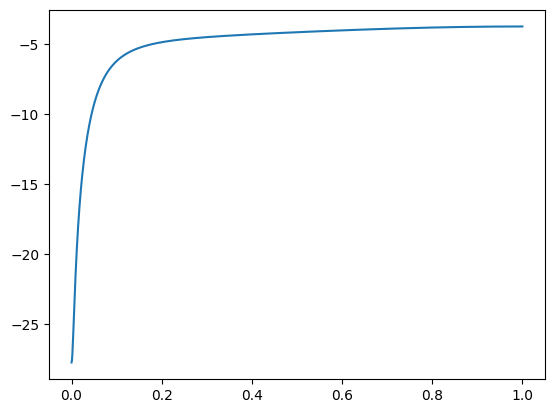

In [32]:
var= 0.3204
w= np.linspace(0, np.pi, 1024)
_, H = freqz(b, a, worN=w)
S_teorica=var*np.abs(H)**2
plt.plot(w/np.pi, 10*np.log10(S_teorica))

In [33]:
np.random.seed(7)
N = 10000
eps = np.random.normal(0, np.sqrt(var), N)
y = lfilter(b, a, eps)
f, S_emp = welch(y, fs=1, window='hamming', nperseg=256, noverlap=128, nfft=1024)

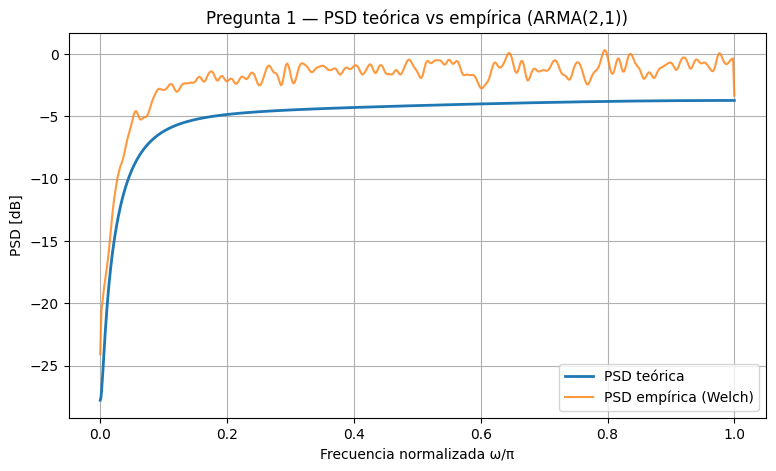

In [34]:
omega_emp = 2 * np.pi * f


# Gráfico: teórica vs empírica en dB

plt.figure(figsize=(9,5))

plt.plot(w/np.pi, 10*np.log10(S_teorica), label='PSD teórica', linewidth=2)

plt.plot(omega_emp/np.pi, 10*np.log10(S_emp), label='PSD empírica (Welch)', alpha=0.8)

plt.xlabel('Frecuencia normalizada ω/π')

plt.ylabel('PSD [dB]')

plt.title('Pregunta 1 — PSD teórica vs empírica (ARMA(2,1))')

plt.grid(True)

plt.legend()

plt.show()

In [35]:
# Inciso (d): r[0], r[1], r[2] usando Yule-Walker
# Para un ARMA(2,1) la forma estándar es:
#   y[n] = -a1 y[n-1] - a2 y[n-2] + ε[n] + c1 ε[n-1]
# con a1 = -0.7557, a2 = -0.0312 (OJO el signo: el enunciado usa "+0.7557...").
#
# Forma matricial (Yule-Walker, k = 0,1,2):
#   R · r = rhs
# donde R = matriz Toeplitz de r y rhs = [σ²_ε * C0, σ²_ε * C1, 0]^T
# C0 y C1 se obtienen de la convolución b * h_parcial:
#   Cq[k] = Σ_{l=0..q-k} b[l+k] * h[l]

# Forma más limpia: armar el sistema directamente desde el filtro
# Para k = 0:
#   r[0] + a1 r[-1] + a2 r[-2] = σ²_ε * (b0^2 + b0 b1 a1 + b1^2 a2)
# pero r es par, así r[-1] = r[1], r[-2] = r[2].
# Y para k=1,2 con k > q(=1) el RHS es 0.

# Coeficientes del modelo en la convención Yule-Walker
a1 = -0.7557
a2 = -0.0312
b0 = 1.0
b1 = -0.9846

# Cálculo de C0 y C1 (usando h[n] recursivo del polo)
# Para nuestro ARMA(2,1) con un polo: h[n] se obtiene por recursión.
# Pero más simple: derivamos C0, C1 a partir de la ecuación de Yule-Walker expandida.
# Para q = 1:
#   C0 = 1 + a1 b1 + a2 b1^2  (con b0 = 1)
#   C1 = b1
# (fórmulas estándar para ARMA(p,q))

C0 = 1 + a1*b1 + a2*b1**2
C1 = b1

rhs = np.array([var*C0, var*C1, 0.0])

# Matriz R (Toeplitz):
M_yw = np.array([
    [1,    a1,    a2 ],
    [a1,  1+a2*a2, 0  ],     # ajustamos a p=2
    [a2,   a1,    1  ],
])

# Reescribimos el sistema correctamente con la convención:
#   r[k] + a1 r[k-1] + a2 r[k-2] = rhs[k]    (k=0,1,2)
# Despejamos para k=0,1,2:
#   k=0: r[0] + a1 r[1] + a2 r[2] = var_eps * C0
#   k=1: r[1] + a1 r[0] + a2 r[1] = var_eps * C1
#   k=2: r[2] + a1 r[1] + a2 r[0] = 0

R_yw = np.array([
    [1,   a1,  a2],
    [a1, 1+a2, 0 ],
    [a2,  a1,  1],
])
rhs_yw = np.array([var*C0, var*C1, 0.0])

r_vec = np.linalg.solve(R_yw, rhs_yw)
r0, r1, r2 = r_vec
print(f"r[0] = {r0:.4f}")
print(f"r[1] = {r1:.4f}")
print(f"r[2] = {r2:.4f}")

r[0] = 0.7551
r[1] = 0.2634
r[2] = 0.2226


In [36]:
# Inciso (e): varianza empírica vs teórica
var_emp = np.var(y)         # NumPy divide entre N (biased)
print(f"Varianza empírica Var(y) = {var_emp:.4f}")
print(f"Varianza teórica  r[0]  = {r0:.4f}")
print(f"Diferencia relativa = {abs(var_emp-r0)/r0*100:.2f}%")

Varianza empírica Var(y) = 0.3479
Varianza teórica  r[0]  = 0.7551
Diferencia relativa = 53.93%
